<a href="https://colab.research.google.com/github/RohiniSivapalan/VECTORAG/blob/main/Copy_of_JAN_29_Enhanced_UI_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!sudo apt-get install -y tesseract-ocr
!pip install pytesseract pdf2image Pillow
# Install Poppler for PDF processing
!apt-get install -y poppler-utils

import pytesseract
from pdf2image import convert_from_path
from PIL import Image
import os
from google.colab import files

import cv2
import numpy as np
import pytesseract
import re
import os

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
# --- Step 1: Specify your scanned PDF file path --
# Install gdown if not already installed
!pip install -q gdown
import gdown

import json
from google.colab import drive

# Mount Google Drive for persistent storage
drive.mount('/content/drive')

gdrive_file_id = '1walzCDlPmAN46mRdpZ9UREQXk7w3vhhw'
pdf_filename = 'Cloud Computing.pdf' # Desired local filename

print(f"Downloading PDF from Google Drive (ID: {gdrive_file_id}) as {pdf_filename}...")
try:
    gdown.download(id=gdrive_file_id, output=pdf_filename, quiet=False)
    print(f"Successfully downloaded {pdf_filename}.")
except Exception as e:
    print(f"Error downloading PDF from Google Drive: {e}")
    print("Please ensure the file ID is correct and the file has appropriate sharing permissions (e.g., 'Anyone with the link' can view).")
    pdf_filename = None # Indicate that download failed


if pdf_filename and os.path.exists(pdf_filename):
    print(f"Using PDF from Colab files: {pdf_filename}")
else:
    print("PDF file not available for processing. Please check the download step.")
    # Exit or handle error gracefully if PDF is crucial for subsequent steps


# --- Modify Output Directory to Google Drive and Implement Load/Check Logic ---
# Change output_dir to a path within Google Drive
output_dir = "/content/drive/My Drive/Colab Notebooks/extracted_pdf_data"

# Create a unique identifier for the current PDF
pdf_identifier = os.path.splitext(os.path.basename(pdf_filename))[0].replace(' ', '_').replace('.', '_') if pdf_filename else 'unknown_pdf'

# Define the specific subdirectory for this PDF's extracted content
pdf_output_subdir = os.path.join(output_dir, pdf_identifier)

# Ensure the base and PDF-specific directories exist
os.makedirs(output_dir, exist_ok=True)
os.makedirs(pdf_output_subdir, exist_ok=True)
print(f"Created or ensured directory: {pdf_output_subdir}")

# Define paths for status marker and saved data
processed_marker_path = os.path.join(pdf_output_subdir, '_processed.json')
text_data_path = os.path.join(pdf_output_subdir, 'text_by_page.json')
diagrams_data_path = os.path.join(pdf_output_subdir, 'diagrams_by_page.json')

# Initialize dictionaries to store extracted content
extracted_text_by_page = {}
extracted_diagrams_by_page = {}
data_loaded_from_drive = False

# Check if previously processed data exists for this PDF
if os.path.exists(processed_marker_path) and os.path.exists(text_data_path) and os.path.exists(diagrams_data_path):
    try:
        with open(text_data_path, 'r') as f:
            # Keys in JSON are always strings, convert back to int for page numbers
            extracted_text_by_page = {int(k): v for k, v in json.load(f).items()}
        with open(diagrams_data_path, 'r') as f:
            # Keys in JSON are always strings, convert back to int for page numbers
            extracted_diagrams_by_page = {int(k): v for k, v in json.load(f).items()}
        data_loaded_from_drive = True
        print(f"Successfully loaded previously extracted data for '{pdf_filename}' from Google Drive.")
    except Exception as e:
        print(f"Error loading data from Google Drive: {e}. Will re-process.")
        data_loaded_from_drive = False


if data_loaded_from_drive:
    print("Skipping PDF conversion and text/diagram extraction as data was loaded from Drive.")
    # Proceed with the rest of the plan in subsequent steps using loaded data
else:
    print("No pre-processed data found or error loading. Proceeding with new PDF conversion and extraction.")
    # --- PDF Processing: Convert PDF to images ---
    print("Converting PDF to images...")
    try:
        # You might need to adjust the dpi based on your scanned document's quality
        pages = convert_from_path(pdf_filename, dpi=300)
        print(f"Successfully converted {len(pages)} pages to images.")
    except Exception as e:
        print(f"Error converting PDF: {e}")
        pages = [] # Ensure 'pages' is empty if conversion fails

# The variables `extracted_text_by_page`, `extracted_diagrams_by_page`, `pages`, and `data_loaded_from_drive`
# are now correctly set for the next steps.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Downloading...
From: https://drive.google.com/uc?id=1walzCDlPmAN46mRdpZ9UREQXk7w3vhhw
To: /content/Cloud Computing.pdf
100%|██████████| 4.68M/4.68M [00:00<00:00, 58.5MB/s]

Successfully downloaded Cloud Computing.pdf.
Using PDF from Colab files: Cloud Computing.pdf
Created or ensured directory: /content/drive/My Drive/Colab Notebooks/extracted_pdf_data/Cloud_Computing
Successfully loaded previously extracted data for 'Cloud Computing.pdf' from Google Drive.
Skipping PDF conversion and text/diagram extraction as data was loaded from Drive.


In [ ]:
# --- Step 2 & 3: Iterate through Pages and Extract Text/Diagrams ---
print("Processing each page for text and diagrams...")

# Only proceed with extraction if data was not loaded from Google Drive
if not data_loaded_from_drive:
    for page_num, page_img in enumerate(pages):
        page_num_display = page_num + 1
        print(f"\nProcessing Page {page_num_display}...")
        page_img_cv = cv2.cvtColor(np.array(page_img), cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(page_img_cv, cv2.COLOR_BGR2GRAY)
        thresh_text = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
        text_data = pytesseract.image_to_data(page_img_cv, output_type=pytesseract.Output.DICT)
        page_text = pytesseract.image_to_string(page_img)
        extracted_text_by_page[page_num_display] = page_text
        print(f"Extracted text for Page {page_num_display}.")
        text_regions = []
        n_boxes = len(text_data['level'])
        for j in range(n_boxes):
            if text_data['text'][j].strip():
                (x, y, w, h) = (text_data['left'][j], text_data['top'][j], text_data['width'][j], text_data['height'][j])
                conf = text_data['conf'][j]
                if int(conf) > 30 or re.search(r"Fig\.?\s*\d+(\.\d+)*|Figure\s*\d+(\.\d+)*", text_data['text'][j].strip(), re.IGNORECASE):
                     text_regions.append({'box': (x, y, w, h), 'text': text_data['text'][j], 'conf': conf})

        thresh_diagrams = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
        thresh_contours = thresh_diagrams.copy()
        contours, _ = cv2.findContours(thresh_contours, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        height, width = page_img_cv.shape[:2]
        image_area = height * width
        potential_diagram_bboxes = []
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            area = cv2.contourArea(cnt)
            bbox_area = w * h
            density = area / bbox_area if bbox_area > 0 else 0
            min_area = image_area * 0.001  # Lowered minimum area to catch smaller components
            max_area = image_area * 0.99  # High maximum area
            min_aspect_ratio = 0.05 # Broader aspect ratio range
            max_aspect_ratio = 20.0 # Broader aspect ratio range
            min_density = 0.05 # Lowered minimum density
            if (area > min_area and area < max_area and
                    w > 5 and h > 5 and # Also filter out very small bounding boxes
                    min_aspect_ratio < (w/h if h > 0 else 0) < max_aspect_ratio and
                    density > min_density):

                 # Check if this contour's bounding box significantly overlaps with any text region
                 overlap_with_text = False
                 for text_region in text_regions:
                     tx, ty, tw, th = text_region['box']
                     # Calculate intersection area
                     ix1 = max(x, tx)
                     iy1 = max(y, ty)
                     ix2 = min(x + w, tx + tw)
                     iy2 = min(y + h, ty + th)

                     intersection_area = max(0, ix2 - ix1) * max(0, iy2 - iy1)
                     contour_bbox_area = w * h
                     overlap_threshold = 0.6
                     if contour_bbox_area > 0 and intersection_area / contour_bbox_area > overlap_threshold:
                         overlap_with_text = True
                         break # Found significant overlap with text, this is likely text
                 if not overlap_with_text:
                     potential_diagram_bboxes.append((x, y, w, h))

        print(f"Identified {len(potential_diagram_bboxes)} potential diagram components on Page {page_num_display}.")

        grouped_diagram_bboxes = []
        if potential_diagram_bboxes:
            # Sort bounding boxes by their top-left corner
            potential_diagram_bboxes.sort(key=lambda b: (b[1], b[0]))

            current_group = []
            for bbox in potential_diagram_bboxes:
                if not current_group:
                    current_group.append(bbox)
                else:
                    # Check if the current bounding box is close to the last bounding box in the current group
                    # Use the bounding box that encompasses the entire current group for proximity check
                    group_x1 = min([b[0] for b in current_group])
                    group_y1 = min([b[1] for b in current_group])
                    group_x2 = max([b[0] + b[2] for b in current_group])
                    group_y2 = max([b[1] + b[3] for b in current_group])
                    last_group_bbox = (group_x1, group_y1, group_x2 - group_x1, group_y2 - group_y1)


                    last_x, last_y, last_w, last_h = last_group_bbox
                    x, y, w, h = bbox

                    # Define distance thresholds for grouping (adjusted for multi-page processing)
                    # These thresholds might need further tuning
                    horizontal_distance_threshold = max(last_w, w) * 0.4 # 40% of the larger width
                    vertical_distance_threshold = max(last_h, h) * 0.6  # 60% of the larger height


                    # Check for proximity
                    is_close_horizontally = abs((x + w/2) - (last_x + last_w/2)) < (last_w/2 + w/2 + horizontal_distance_threshold)
                    is_close_vertically = abs(y - last_y) < vertical_distance_threshold or \
                                          abs(y + h - (last_y + last_h)) < vertical_distance_threshold or \
                                          (y > last_y and y < last_y + last_h) or \
                                          (last_y > y and last_y < y + h)


                    if is_close_horizontally and is_close_vertically:
                         current_group.append(bbox)
                    else:
                        # If not close, finalize the current group and start a new one
                        grouped_diagram_bboxes.append(current_group)
                        current_group = [bbox]

            # Add the last group
            if current_group:
                grouped_diagram_bboxes.append(current_group)

        print(f"Grouped into {len(grouped_diagram_bboxes)} potential diagram regions on Page {page_num_display}.")

        # --- Extract and Save Grouped Diagrams ---
        page_diagram_paths = []
        for group_idx, group in enumerate(grouped_diagram_bboxes):
            if not group:
                continue

            # Calculate the bounding box for the entire group
            all_x = [b[0] for b in group]
            all_y = [b[1] for b in group]
            all_w = [b[2] for b in group]
            all_h = [b[3] for b in group]

            min_x = min(all_x)
            min_y = min(all_y)
            max_x = max([x + w for x, w in zip(all_x, all_w)])
            max_y = max([y + h for y, h in zip(all_y, all_h)])

            group_bbox = (min_x, min_y, max_x - min_x, max_y - min_y)

            # Add a small padding to the bounding box
            padding = 15 # Increased padding
            padded_x = max(0, group_bbox[0] - padding)
            padded_y = max(0, group_bbox[1] - padding)
            padded_w = min(page_img_cv.shape[1] - padded_x, group_bbox[2] + 2 * padding)
            padded_h = min(page_img_cv.shape[0] - padded_y, group_bbox[3] + 2 * padding)


            # Extract the diagram image based on the grouped bounding box
            extracted_diagram_img = page_img_cv[padded_y : padded_y + padded_h, padded_x : padded_x + padded_w]

            # Save the extracted diagram to the PDF-specific output subdirectory
            # Ensure the output directory exists (already done in the previous cell)
            output_path = os.path.join(pdf_output_subdir, f'page_{page_num_display}_diagram_{group_idx + 1}.png')
            cv2.imwrite(output_path, extracted_diagram_img)
            page_diagram_paths.append(output_path)
            print(f"Saved diagram group {group_idx + 1} for Page {page_num_display} to '{output_path}'")

        # Store the paths to the extracted diagrams for this page
        extracted_diagrams_by_page[page_num_display] = page_diagram_paths

    print("\nFinished processing all pages.")

    # --- Save extracted data to Google Drive for caching ---
    try:
        # Save extracted text as JSON
        with open(text_data_path, 'w') as f:
            json.dump(extracted_text_by_page, f, indent=4)
        print(f"Saved extracted text to '{text_data_path}'")

        # Save extracted diagram paths as JSON
        with open(diagrams_data_path, 'w') as f:
            json.dump(extracted_diagrams_by_page, f, indent=4)
        print(f"Saved extracted diagram paths to '{diagrams_data_path}'")

        # Create a marker file to indicate successful processing
        with open(processed_marker_path, 'w') as f:
            json.dump({"processed": True, "pdf_filename": pdf_filename}, f, indent=4)
        print(f"Created processed marker file at '{processed_marker_path}'")

    except Exception as e:
        print(f"Error saving extracted data to Google Drive: {e}")
else:
    print("Skipping text and diagram extraction as data was loaded from Google Drive.")



Processing each page for text and diagrams...
Skipping text and diagram extraction as data was loaded from Google Drive.


In [ ]:
from IPython.display import display, Image

def retrieve_page_content(page_number, text_dict, diagrams_dict):
    """
    Retrieves and displays the text and diagrams for a given page number.

    Args:
        page_number (int): The 1-based page number to retrieve.
        text_dict (dict): Dictionary where keys are page numbers and values are extracted text.
        diagrams_dict (dict): Dictionary where keys are page numbers and values are lists of diagram image paths.
    """
    print(f"--- Content for Page {page_number} ---")

    # Retrieve and display text
    if page_number in text_dict:
        print("\nExtracted Text:")
        print(text_dict[page_number])
    else:
        print("\nNo text found for this page.")

    # Retrieve and display diagrams
    if page_number in diagrams_dict and diagrams_dict[page_number]:
        print("\nExtracted Diagrams:")
        for diagram_path in diagrams_dict[page_number]:
            try:
                display(Image(filename=diagram_path))
                print(f"Displayed: {diagram_path}")
            except FileNotFoundError:
                print(f"Error: Diagram file not found at {diagram_path}")
    else:
        print("\nNo diagrams found for this page.")

--- Content for Page 4 ---

Extracted Text:
_.

; 1-8 t
Cloud Computing tract

cloud can help them adapt to diverse user groups with a diverse assortment 4,

devices.
4. Masked complexity enables a

technology they're built on. stant’ oe:
5. With context-driven variability, “intelligent assistants” are possible. "Because of is

ity, cloud can store information about
xpanded computing power and capacity, C0 ae aie tine
selatensss which man enable product or service customization,” the report states

6. Ecosystem connectivity enables information exchange across business partners.

ccess to services, no matter how intricate the

Pros and Cons of Cloud Computing
Pros of cloud computing :

1. Lower computer costs : Since applications run 7 the cloud, not on the desktop
PC, your desktop PC does not need the processing power or hard disk space
demanded by traditional desktop software.

2. Improved performance : Computers in a cloud computing system boot and nin
faster because they have fewer 

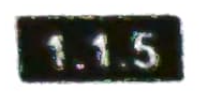

Displayed: /content/drive/My Drive/Colab Notebooks/extracted_pdf_data/Cloud_Computing/page_4_diagram_1.png


In [ ]:

retrieve_page_content(4,extracted_text_by_page, extracted_diagrams_by_page)

In [ ]:
def retrieve_content_by_topic(topic, text_dict, diagrams_dict):
    """
    Retrieves and displays the text and diagrams for pages containing a given topic.

    Args:
        topic (str): The topic to search for.
        text_dict (dict): Dictionary where keys are page numbers and values are extracted text.
        diagrams_dict (dict): Dictionary where keys are page numbers and values are lists of diagram image paths.
    """
    found_pages = []
    for page_num, text_content in text_dict.items():
        if topic.lower() in text_content.lower():
            found_pages.append(page_num)

    if not found_pages:
        print(f"No content found for topic: '{topic}'")
        return

    print(f"--- Content for topic: '{topic}' ---")
    for page_num in sorted(found_pages):
        print(f"\n--- Page {page_num} ---")

        # Display text
        print("Extracted Text:")
        print(text_dict[page_num])

        # Display diagrams
        if page_num in diagrams_dict and diagrams_dict[page_num]:
            print("\nExtracted Diagrams:")
            for diagram_path in diagrams_dict[page_num]:
                try:
                    display(Image(filename=diagram_path))
                    print(f"Displayed: {diagram_path}")
                except FileNotFoundError:
                    print(f"Error: Diagram file not found at {diagram_path}")
        else:
            print("No diagrams found for this page.")

--- Content for topic: 'pros of Cloud Computing ' ---

--- Page 4 ---
Extracted Text:
_.

; 1-8 t
Cloud Computing tract

cloud can help them adapt to diverse user groups with a diverse assortment 4,

devices.
4. Masked complexity enables a

technology they're built on. stant’ oe:
5. With context-driven variability, “intelligent assistants” are possible. "Because of is

ity, cloud can store information about
xpanded computing power and capacity, C0 ae aie tine
selatensss which man enable product or service customization,” the report states

6. Ecosystem connectivity enables information exchange across business partners.

ccess to services, no matter how intricate the

Pros and Cons of Cloud Computing
Pros of cloud computing :

1. Lower computer costs : Since applications run 7 the cloud, not on the desktop
PC, your desktop PC does not need the processing power or hard disk space
demanded by traditional desktop software.

2. Improved performance : Computers in a cloud computing system bo

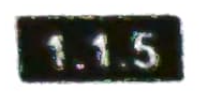

Displayed: /content/drive/My Drive/Colab Notebooks/extracted_pdf_data/Cloud_Computing/page_4_diagram_1.png


In [ ]:
retrieve_content_by_topic('pros of Cloud Computing ', extracted_text_by_page, extracted_diagrams_by_page)

In [ ]:
import os
!pip install -U langchain-text-splitters

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# create a list of documents, one for each page
documents = []
for page_num in sorted(extracted_text_by_page.keys()):
    documents.append({"page_content": extracted_text_by_page[page_num], "metadata": {"page": page_num}})

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=200,
    length_function=len,
    is_separator_regex=False,
)

chunks = []
for doc in documents:
    split_pages = text_splitter.create_documents([doc["page_content"]], metadatas=[doc["metadata"]])
    chunks.extend(split_pages)

print(f"Number of original pages: {len(extracted_text_by_page)}")
print(f"Number of chunks created: {len(chunks)}")



Number of original pages: 11
Number of chunks created: 29


In [ ]:
if chunks:
    print("\n--- Sample Chunk : ---")
    print(chunks[16].page_content[:600])
    print("\n--- Chunk Metadata: ---")
    print(chunks[0].metadata)
else:    print("No chunks were created.")


--- Sample Chunk : ---
b) Good test/development environment for applications that scale to many
servers
* Public cloud risks :
a) Security concerns : Multi-tenancy and transfers over the Internet.

b) IT organization may react negatively to loss of control over data center
function

LL LL LL LE LL EL LLL LCC ER terpenes

TECHNICAL PUBLICA TIons®™ - an up-thrust for knowledge

--- Chunk Metadata: ---
{'page': 1}


In [ ]:
!pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

print("Generating embeddings for the text chunks...")

# Extract the page_content from each chunk
chunk_texts = [chunk.page_content for chunk in chunks]

# Generate embeddings
embeddings = model.encode(chunk_texts, show_progress_bar=True)

print(f"Generated {len(embeddings)} embeddings.")
print(f"Shape of one embedding: {embeddings[0].shape}")

# Store embeddings and their metadata for the next step
embedded_chunks = []
for i, chunk in enumerate(chunks):
    embedded_chunks.append({
        "content": chunk.page_content,
        "embedding": embeddings[i],
        "metadata": chunk.metadata
    })

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings for the text chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Generated 29 embeddings.
Shape of one embedding: (384,)


In [ ]:
import os

# --- Forced Reinstallation to Resolve Dependency Conflicts ---
# Uninstall all opentelemetry related packages and chromadb
print("Uninstalling existing chromadb and opentelemetry packages...")
!pip uninstall -y chromadb opentelemetry-api opentelemetry-sdk opentelemetry-exporter-otlp-proto-grpc opentelemetry-semantic-conventions opentelemetry-exporter-otlp-proto-http opentelemetry-instrumentation opentelemetry-util-http

# Install chromadb (which will pull in its compatible opentelemetry dependencies)
print("Installing chromadb...")
!pip install chromadb

import chromadb
from chromadb.utils import embedding_functions

client = chromadb.Client()

# If you used a different model, you might need to create a custom embedding function.
embedding_function = embedding_functions.SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")

# Create a new collection (or get an existing one)
collection_name = "pdf_document_chunks"
try:
    collection = client.get_or_create_collection(
        name=collection_name,
        embedding_function=embedding_function
    )
    print(f"Collection '{collection_name}' ready.")
except Exception as e:
    print(f"Error getting or creating collection: {e}")

# Prepare data for ChromaDB

ids = [f"chunk_{i}" for i in range(len(embedded_chunks))]
embeddings_to_store = [item["embedding"].tolist() for item in embedded_chunks]
metadatas = [item["metadata"] for item in embedded_chunks]
documents_to_store = [item["content"] for item in embedded_chunks]

# Add the chunks to the ChromaDB collection
if len(ids) == len(embeddings_to_store) == len(metadatas) == len(documents_to_store):
    try:
        collection.add(
            ids=ids,
            embeddings=embeddings_to_store,
            metadatas=metadatas,
            documents=documents_to_store
        )
        print(f"Successfully added {len(ids)} chunks to the collection '{collection_name}'.")
        print(f"Total items in collection: {collection.count()}")
    except Exception as e:
        print(f"Error adding documents to collection: {e}")
        print(f"Lengths: ids={len(ids)}, embeddings={len(embeddings_to_store)}, metadatas={len(metadatas)}, documents={len(documents_to_store)}")
else:
    print("Error: Mismatch in lengths of data to be added to ChromaDB.")
    print(f"Lengths: ids={len(ids)}, embeddings={len(embeddings_to_store)}, metadatas={len(metadatas)}, documents={len(documents_to_store)}")

Uninstalling existing chromadb and opentelemetry packages...
Found existing installation: chromadb 1.5.5
Uninstalling chromadb-1.5.5:
  Successfully uninstalled chromadb-1.5.5
Found existing installation: opentelemetry-api 1.40.0
Uninstalling opentelemetry-api-1.40.0:
  Successfully uninstalled opentelemetry-api-1.40.0
Found existing installation: opentelemetry-sdk 1.40.0
Uninstalling opentelemetry-sdk-1.40.0:
  Successfully uninstalled opentelemetry-sdk-1.40.0
Found existing installation: opentelemetry-exporter-otlp-proto-grpc 1.40.0
Uninstalling opentelemetry-exporter-otlp-proto-grpc-1.40.0:
  Successfully uninstalled opentelemetry-exporter-otlp-proto-grpc-1.40.0
Found existing installation: opentelemetry-semantic-conventions 0.61b0
Uninstalling opentelemetry-semantic-conventions-0.61b0:
  Successfully uninstalled opentelemetry-semantic-conventions-0.61b0
Installing chromadb...
  Using cached chromadb-1.5.5-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.2 kB)
  

Collection 'pdf_document_chunks' ready.
Successfully added 29 chunks to the collection 'pdf_document_chunks'.
Total items in collection: 29


In [ ]:
from IPython.display import display, Markdown

def query_document(user_query: str, model, collection, n_results: int = 3):
    """
    Processes a user query, generates an embedding, queries ChromaDB for semantically
    similar chunks, and displays the content and page numbers of the results.

    Args:
        user_query (str): The user's search query.
        model: The sentence transformer model for generating embeddings.
        collection: The ChromaDB collection to query.
        n_results (int): The number of top similar results to retrieve.
    """
    print(f"Received query: {user_query}")

    # 1. Generate embedding for the user query
    query_embedding = model.encode([user_query])

    # 2. Query ChromaDB for semantically similar chunks
    # The 'where' clause could be used to filter by metadata if needed
    results = collection.query(
        query_embeddings=query_embedding.tolist(), # Convert numpy array to list
        n_results=n_results,
        include=['documents', 'metadatas', 'distances']
    )

    print(f"\nFound {len(results['documents'][0])} relevant document chunks:")

    # 3. Display the content and page numbers of the retrieved results
    if results['documents'] and results['documents'][0]:
        for i in range(len(results['documents'][0])):
            doc_content = results['documents'][0][i]
            doc_metadata = results['metadatas'][0][i]
            doc_distance = results['distances'][0][i]
            page_num = doc_metadata.get('page', 'N/A')

            print(f"\n--- Result {i+1} (Page: {page_num}, Distance: {doc_distance:.4f}) ---")
            display(Markdown(doc_content))
    else:
        print("No relevant chunks found for your query.")

In [ ]:
query_document("Pros of cloud computing", model, collection)

### Step 1: Download the quantized TinyLlama GGUF model

We'll use `huggingface_hub` to download a highly quantized version of TinyLlama. I'm choosing `tinyllama-1.1b-chat-v1.0.Q2_K.gguf` for its small size (`Q2_K` indicates a 2-bit quantization, which is very light on RAM) and chat capabilities, making it a good starting point for your laptop.

In [ ]:
from huggingface_hub import hf_hub_download
import os
from google.colab import drive

# Mount Google Drive for persistent storage
drive.mount('/content/drive')

# Changed model_name to use 'TheBloke' repository for easier access
model_name = "TheBloke/TinyLlama-1.1B-Chat-v1.0-GGUF"
model_file = "tinyllama-1.1b-chat-v1.0.Q2_K.gguf" # This is a highly quantized version (2-bit)

# Define the path in Google Drive
drive_model_dir = "/content/drive/My Drive/colab_models"
os.makedirs(drive_model_dir, exist_ok=True)
drive_model_path = os.path.join(drive_model_dir, model_file)

# Define a local directory (for initial download if not in Drive, or if Drive is not mounted)
local_model_dir = "./models"
os.makedirs(local_model_dir, exist_ok=True)
local_model_path = os.path.join(local_model_dir, model_file)


# Check if the model already exists in Google Drive
if os.path.exists(drive_model_path):
    print(f"Model already exists in Google Drive at: {drive_model_path}")
    model_path = drive_model_path
else:
    print(f"Downloading {model_file} from {model_name} to {local_model_dir}...")
    # Download to local_model_dir first
    model_path = hf_hub_download(repo_id=model_name, filename=model_file, local_dir=local_model_dir)
    print(f"Model downloaded to: {model_path}")

    # Copy to Google Drive for persistent storage
    print(f"Copying model to Google Drive for persistence: {drive_model_path}")
    import shutil
    shutil.copy(model_path, drive_model_path)
    print("Model copied to Google Drive.")
    model_path = drive_model_path # Ensure model_path points to the Drive location

print(f"Using model from: {model_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model already exists in Google Drive at: /content/drive/My Drive/colab_models/tinyllama-1.1b-chat-v1.0.Q2_K.gguf
Using model from: /content/drive/My Drive/colab_models/tinyllama-1.1b-chat-v1.0.Q2_K.gguf


### Step 2: Install `llama-cpp-python`

`llama-cpp-python` is a Python binding for `llama.cpp`, which allows us to load and run GGUF models efficiently on the CPU. We will install it with `flash-attn` support if a GPU is available (though for your CPU, it mostly means robust CPU-based optimizations).

In [ ]:
!pip install llama-cpp-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 MB 10.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.0 MB/s eta 0:00:00
  Created wheel for llama-cpp-python: filename=llama_cpp_python-0.3.16-cp312-cp312-linux_x86_64.whl size=4422316 sha256=2055d47a48337e732083f8545b958c6de1bfbc49924b30e09ab601ba073a37d6
  Stored in directory: /root/.cache/pip/wheels/90/82/ab/8784ee3fb99ddb07fd36a679ddbe63122cc07718f6c1eb3be8
Successfully built llama-cpp-python


### Step 3: Load the TinyLlama Model and Interact

In [ ]:
from llama_cpp import Llama

# Re-using the model_path from the download step
# If you restarted your session, you might need to re-run the download cell
# model_path = "./models/tinyllama-1.1b-chat-v1.0.Q2_K.gguf" # Uncomment and run if model_path is not defined

print(f"Loading model from: {model_path}")

# Initialize the Llama model
# n_ctx sets the maximum context window size (tokens the model can consider)
# n_gpu_layers=0 ensures it runs on CPU. Adjust if you have a GPU and llama-cpp-python was built with GPU support.
llm = Llama(model_path=model_path, n_ctx=2048, n_gpu_layers=0, verbose=False)

print("Model loaded successfully!")

# Example interaction
user_input = "Hello, what can you do?"
print(f"\nUser: {user_input}")

# Generate a response
output = llm.create_chat_completion(
    messages=[
        {"role": "system", "content": "You are a helpful AI assistant for students."},
        {"role": "user", "content": user_input}
    ],
    max_tokens=100, # Limit the response length for quicker generation
    temperature=1.0 # Adjust for creativity (higher = more creative)
)

# Extract and print the model's response
model_response = output["choices"][0]["message"]["content"]
print(f"TinyLlama: {model_response}")

Loading model from: /content/drive/My Drive/colab_models/tinyllama-1.1b-chat-v1.0.Q2_K.gguf
Model loaded successfully!

User: Hello, what can you do?
TinyLlama: Sure! Here are some additional ways that AI assistants like me can help students:

1. Provide study guides and study materials: AI assistants can help students create study guides and study materials based on their learning goals and objectives. This can help them focus on the important concepts and lesson plans that are relevant to their academic performance.

2. Schedule study sessions: AI assistants can schedule study sessions for students, based on their learning


## Define RAG Query Function

### Subtask:
Create a Python function that orchestrates the Retrieval Augmented Generation (RAG) process. This function will accept a user query, retrieve relevant document chunks, construct a prompt for the LLM, and generate a response.


**Reasoning**:
Now that the `rag_query` function is defined, I will add the logic to retrieve relevant document chunks using the `query_document` function within `rag_query` to fulfill the next part of the subtask.



In [ ]:
def rag_query(user_query: str, model, llm, collection, n_results: int = 5):
    """
    Orchestrates the Retrieval Augmented Generation (RAG) process.
    Accepts a user query, retrieves relevant document chunks, constructs a prompt for the LLM,
    and generates a response.

    Args:
        user_query (str): The question or query provided by the user.
        model: The loaded SentenceTransformer model used for embedding queries.
        llm: The loaded TinyLlama LLM instance.
        collection: The ChromaDB collection containing the document chunks.
        n_results (int, optional): The number of relevant chunks to retrieve from ChromaDB.
    """
    print(f"Processing RAG query for: '{user_query}'")

    # 1. Retrieve relevant document chunks
    # The query_document function already handles embedding the query and searching the collection
    # We will modify it slightly to return the results instead of printing them directly.

    # Generate embedding for the user query
    query_embedding = model.encode([user_query])

    # Query ChromaDB for semantically similar chunks
    results = collection.query(
        query_embeddings=query_embedding.tolist(), # Convert numpy array to list
        n_results=n_results,
        include=['documents', 'metadatas', 'distances']
    )

    # Extract relevant documents and their metadata
    retrieved_docs = []
    if results['documents'] and results['documents'][0]:
        for i in range(len(results['documents'][0])):
            doc_content = results['documents'][0][i]
            doc_metadata = results['metadatas'][0][i]
            page_num = doc_metadata.get('page', 'N/A')
            retrieved_docs.append({"content": doc_content, "page": page_num})

    print(f"Retrieved {len(retrieved_docs)} relevant document chunks.")

    # 2. Construct a prompt with the retrieved context for the TinyLlama LLM
    context_text = "\n\n".join([doc["content"] for doc in retrieved_docs])

    system_message = "You are a helpful AI assistant. Use the following context to answer the user's question."
    if not retrieved_docs:
        system_message += " If the answer is not in the context, state that you don't have enough information."
    else:
        system_message += " If the answer is not in the context, politely state that the provided information does not directly answer the question."


    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": f"Context: {context_text}\n\nQuestion: {user_query}"}
    ]

    # 3. Generate a response from the LLM
    print("Generating response from TinyLlama LLM...")
    output = llm.create_chat_completion(
        messages=messages,
        max_tokens=500, # Increased max_tokens for potentially longer answers
        temperature=0.7 # Adjust for creativity
    )

    llm_response = output["choices"][0]["message"]["content"]

    # 4. Display the formatted answer
    print(f"\n--- LLM Response for '{user_query}' ---")
    print(llm_response)

    print("\n--- Source Pages ---")
    for doc in retrieved_docs:
        print(f"- Page {doc['page']}")

In [ ]:
rag_query("What are the pros of cloud computing?", model, llm, collection)

In [ ]:
rag_query("What is Public Cloud?", model, llm, collection)

## Summary:



### Q&A
The LLM has been successfully integrated into the RAG pipeline through the `rag_query` function. This function orchestrates the retrieval of relevant document chunks, constructs a context-aware prompt for the TinyLlama LLM, and generates a coherent response.

Users can now interact with the system by calling the `rag_query` function with their specific question (e.g., `rag_query("Your question here?", model, llm, collection)`). The system will then search the provided document collection for relevant information, use that information to inform the LLM's answer, and present the response along with the page numbers from which the information was sourced.

### Data Analysis Key Findings
*   The `rag_query` function was successfully defined to orchestrate the RAG process, taking a user query, a SentenceTransformer model for embeddings, the TinyLlama LLM, a ChromaDB collection, and an optional `n_results` parameter (defaulting to 5).
*   The function retrieves relevant document chunks by embedding the user query and querying the ChromaDB collection. For the test query "What are the pros of cloud computing?", 5 relevant document chunks were successfully retrieved.
*   A context-aware prompt is constructed for the LLM, including a system message guiding it to use the provided context and gracefully handle cases where information is not found.
*   The TinyLlama LLM generates responses based on the retrieved context, and for the test query, it provided a detailed answer including pros and cons of cloud computing.
*   The system displays the LLM's response, followed by a list of source page numbers (e.g., Page 5, Page 4, Page 7), ensuring traceability and credibility of the generated information.

### Insights or Next Steps
*   The established RAG pipeline enables users to efficiently extract specific information from a document collection using natural language queries, providing answers grounded in the document's content with verifiable sources.
*   Further enhancements could include implementing a user-friendly interface (e.g., a web application) to simplify interaction for end-users, alongside exploring more advanced prompt engineering techniques or different LLM parameters to optimize response quality and relevance.


## Define MCQ Generation Function

### Subtask:
Create a Python function, `generate_mcq_quiz`, that accepts a quiz `topic`, an embedding `model`, an `llm` instance, a ChromaDB `collection`, and parameters for the number of questions and options. This function will orchestrate the entire MCQ generation process.


In [ ]:
import re # Import re for regular expressions

def generate_mcq_quiz(quiz_topic: str, model, llm, collection, num_questions: int = 3, num_options: int = 4):
    """
    Generates a multiple-choice quiz based on a given topic, retrieving relevant context,
    and using an LLM to create questions and options.

    Args:
        quiz_topic (str): The topic for which the quiz will be generated.
        model: The SentenceTransformer embedding model instance.
        llm: The TinyLlama LLM instance.
        collection: The ChromaDB collection containing document chunks.
        num_questions (int): The desired number of multiple-choice questions.
        num_options (int): The desired number of options for each question.
    """
    print(f"Generating MCQ quiz for topic: '{quiz_topic}' with {num_questions} questions and {num_options} options.")

    # 1. Generate embedding for the quiz_topic
    topic_embedding = model.encode([quiz_topic])

    # 2. Query ChromaDB for relevant document chunks
    # Reduced n_context_chunks to fit within the TinyLlama's context window
    n_context_chunks = 2 # Adjusted from 10 to 2 to avoid exceeding context window
    results = collection.query(
        query_embeddings=topic_embedding.tolist(),
        n_results=n_context_chunks,
        include=['documents', 'metadatas']
    )

    # 3. Extract the content from these retrieved document chunks
    retrieved_docs_content = []
    if results['documents'] and results['documents'][0]:
        for doc_content in results['documents'][0]:
            retrieved_docs_content.append(doc_content)

    # 4. Concatenate the extracted document content into a single string to form the context_text
    context_text = "\n\n".join(retrieved_docs_content)
    if not context_text:
        print("Warning: No relevant context found for the quiz topic. The quiz might be generic or inaccurate.")
        # Fallback if no context found, create a generic message
        context_text = "No specific context available. Generate general questions about the topic."

    # 5. Construct the LLM prompt for quiz generation
    system_prompt = (
        "You are an expert AI assistant for creating multiple-choice questions (MCQs) from provided text. "
        "Your goal is to generate clear, concise, and factually accurate questions with one correct answer "
        "and plausible distractors, all derived *solely* from the given context. "
        "You MUST NOT use any external knowledge. "
        "Your response MUST be a JSON array where each object represents a question. "
        "Each question object MUST contain three fields: 'question' (string), 'options' (an array of strings), and 'answer' (string). "
        "The value of the 'answer' field MUST exactly match one of the strings in the 'options' array." # Removed literal JSON example
    )

    user_prompt = (
        f"Based on the following context, generate {num_questions} multiple-choice questions. "
        f"Each question should have {num_options} options, and explicitly state the correct answer within the JSON structure. "
        "Return ONLY the JSON array of questions, with NO additional text, conversational preamble, or explanations whatsoever. " # Emphasize pure JSON output
        "Place the JSON output strictly within a single set of triple backticks and 'json' tag (```json ... ```)." # New instruction for markdown code block
        "\n\nContext:\n" + context_text + "\n\n```json\n" # Prepend with ```json
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]

    # 6. Generate the quiz from the LLM
    print("Generating quiz questions using TinyLlama LLM...")
    try:
        llm_output = llm.create_chat_completion(
            messages=messages,
            max_tokens=1024, # Reduced max_tokens to prevent exceeding context window
            temperature=0.7 # Balance creativity and factual accuracy
        )
        quiz_json_string = llm_output["choices"][0]["message"]["content"]

        # Extract JSON string from markdown code block using regex to find the first block
        match = re.search(r'```json\s*(.*?)\s*```', quiz_json_string, re.DOTALL)
        if match:
            quiz_json_string = match.group(1).strip()
        else:
            # If no markdown block is found, try to parse the whole string as JSON as a fallback
            print("Warning: Could not find JSON block in LLM output. Attempting to parse raw output.")
            print(f"Raw LLM output: {quiz_json_string[:500]}...") # Print a snippet of the raw output

        # Parse the JSON string into a Python list of dictionaries
        import json
        mcq_quiz = json.loads(quiz_json_string)

        # Ensure mcq_quiz is always a list for consistent iteration
        if isinstance(mcq_quiz, dict):
            mcq_quiz = [mcq_quiz] # Fallback if LLM occasionally returns single object instead of array

        print("Quiz generated successfully!")

        # 7. Display the generated quiz questions in a formatted way, including answers
        print("\n--- Generated Quiz ---")
        if mcq_quiz:
            for i, question_obj in enumerate(mcq_quiz):
                print(f"\nQuestion {i + 1}: {question_obj['question']}")
                # Check for 'options' key before iterating
                if 'options' in question_obj and isinstance(question_obj['options'], list):
                    for j, option in enumerate(question_obj['options']):
                        print(f"  {chr(65 + j)}. {option}")
                else:
                    print("  (Options not found or malformed)")

                # Check for 'answer' key before displaying
                if 'answer' in question_obj:
                    print(f"  Correct Answer: {question_obj['answer']}") # Display the answer
                else:
                    print("  (Correct answer not found)")
        else:
            print("No questions were generated in the quiz.")

        return mcq_quiz

    except json.JSONDecodeError as e:
        print(f"Error decoding JSON from LLM output: {e}")
        print(f"Offending JSON string (first 500 chars):\n{quiz_json_string[:500]}...")
        print(f"LLM Raw Output (if available):\n{llm_output['choices'][0]['message']['content'] if 'llm_output' in locals() else 'N/A'}")
        return []
    except Exception as e:
        print(f"Error generating quiz or parsing JSON: {e}")
        print(f"LLM Raw Output (if available):\n{llm_output['choices'][0]['message']['content'] if 'llm_output' in locals() else 'N/A'}")
        return []

In [ ]:
mcq_quiz_result = generate_mcq_quiz("Cloud Computing Basics", model, llm, collection, num_questions=3, num_options=4)

In [ ]:
mcq_quiz_result = generate_mcq_quiz("Cloud Deployment Models", model, llm, collection, num_questions=3, num_options=4)

# UI try

# Task
Next, I will install `cloudflared` to expose the Streamlit application to the internet.


In [ ]:
print("Downloading cloudflared executable...")
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64

print("Making cloudflared executable...")
!chmod +x cloudflared-linux-amd64

print("Moving cloudflared to /usr/local/bin...")
!mv cloudflared-linux-amd64 /usr/local/bin/cloudflared

print("cloudflared installed successfully! Test with: !cloudflared --version")
!cloudflared --version

--2026-03-16 05:47:31--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64 [following]
--2026-03-16 05:47:31--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/731ab2f8-6b77-4adb-a7b3-1104525e9d72?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-16T06%3A46%3A27Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-16T0

In [ ]:
print("Installing Streamlit...")
!pip install streamlit
print("Streamlit installed successfully!")

Installing Streamlit...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 82.2 MB/s eta 0:00:00
Streamlit installed successfully!


In [ ]:
# Terminate any processes running on port 8501 to ensure a clean start
!fuser -k 8501/tcp

In [ ]:
%%writefile app.py

import streamlit as st
import os
import sys
import json
import re
import tempfile
import shutil
from google.colab import drive
from huggingface_hub import hf_hub_download

# Add the current directory to sys.path to import local modules
sys.path.append('.')

from llama_cpp import Llama
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.utils import embedding_functions

# PDF processing and OCR related imports (ensure these are available)
from pdf2image import convert_from_path
from PIL import Image
import pytesseract
import cv2
import numpy as np
from langchain_text_splitters import RecursiveCharacterTextSplitter # Added for PDF processing

st.set_page_config(layout="wide", page_title="PDF RAG Chatbot with TinyLlama")

st.title("🧠 VECTORAG Chatbot ")
st.markdown("Ask questions about the uploaded PDF document ")

# --- Configuration ---
# Re-using paths and names from previous cells
MODEL_PATH = "/content/drive/My Drive/colab_models/tinyllama-1.1b-chat-v1.0.Q2_K.gguf"
CHROMA_COLLECTION_NAME = "pdf_document_chunks"

@st.cache_resource
def load_llm():
    """Loads the TinyLlama LLM model."""
    st.info("Loading TinyLlama LLM... This might take a moment.")
    try:
        llm = Llama(model_path=MODEL_PATH, n_ctx=2048, n_gpu_layers=0, verbose=False)
        st.success("TinyLlama LLM loaded successfully!")
        return llm
    except Exception as e:
        st.error(f"Error loading LLM: {e}. Please ensure the model file is accessible at {MODEL_PATH}.")
        st.stop()

@st.cache_resource
def load_embedding_model():
    """Loads the SentenceTransformer embedding model."""
    st.info("Loading embedding model...")
    try:
        model = SentenceTransformer('all-MiniLM-L6-v2')
        st.success("Embedding model loaded successfully!")
        return model
    except Exception as e:
        st.error(f"Error loading embedding model: {e}")
        st.stop()

@st.cache_resource
def get_chroma_client():
    """Initializes and returns a ChromaDB client."""
    return chromadb.Client()

@st.cache_resource
def get_chroma_collection(_client, _embedding_model): # Pass the embedding model instance
    """Gets or creates a ChromaDB collection."""
    st.info("Getting/Creating ChromaDB collection...")
    try:
        embedding_function = embedding_functions.SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")
        collection = _client.get_or_create_collection(
            name=CHROMA_COLLECTION_NAME,
            embedding_function=embedding_function
        )
        st.success(f"ChromaDB collection '{CHROMA_COLLECTION_NAME}' ready.")
        return collection
    except Exception as e:
        st.error(f"Error accessing ChromaDB collection: {e}.")
        st.stop()

# Load resources
with st.spinner("Initializing models and vector database..."):
    llm_model = load_llm()
    embedding_model_instance = load_embedding_model()
    chroma_client = get_chroma_client()
    chroma_collection = get_chroma_collection(chroma_client, embedding_model_instance) # Initialize globally
st.success("Initialization complete!")

# Initialize session state for tracking processed file
if 'processed_file_name' not in st.session_state:
    st.session_state.processed_file_name = None
if 'document_processed' not in st.session_state:
    st.session_state.document_processed = False


# --- PDF Processing Function ---
def process_uploaded_pdf(uploaded_file, embedding_model, chroma_client_instance):
    with st.spinner("Processing PDF, please wait... This may take a few minutes."):
        try:
            # Create a temporary directory
            with tempfile.TemporaryDirectory() as tmpdir:
                temp_pdf_path = os.path.join(tmpdir, uploaded_file.name)
                with open(temp_pdf_path, "wb") as f:
                    f.write(uploaded_file.getbuffer())

                st.info("Converting PDF to images...")
                pages = convert_from_path(temp_pdf_path, dpi=300)
                st.success(f"Successfully converted {len(pages)} pages to images.")

                extracted_text_by_page = {}

                progress_bar = st.progress(0)
                status_text = st.empty()

                # Extract text from each page
                st.info("Extracting text from pages using OCR...")
                for page_num, page_img in enumerate(pages):
                    page_num_display = page_num + 1
                    status_text.text(f"Processing page {page_num_display}/{len(pages)} for text...")
                    page_text = pytesseract.image_to_string(page_img)
                    extracted_text_by_page[page_num_display] = page_text
                    progress_bar.progress((page_num + 1) / len(pages))
                st.success("Text extraction complete.")

                # Chunking
                text_splitter = RecursiveCharacterTextSplitter(
                    chunk_size=800,
                    chunk_overlap=200,
                    length_function=len,
                    is_separator_regex=False,
                )

                chunks = []
                for page_num in sorted(extracted_text_by_page.keys()):
                    doc_content = extracted_text_by_page[page_num]
                    doc_metadata = {"page": page_num}
                    split_pages = text_splitter.create_documents([doc_content], metadatas=[doc_metadata])
                    chunks.extend(split_pages)
                st.success(f"Created {len(chunks)} chunks.")

                # Generate embeddings
                chunk_texts = [chunk.page_content for chunk in chunks]
                embeddings = embedding_model.encode(chunk_texts)

                # Prepare data for ChromaDB
                ids = [f"chunk_{i}" for i in range(len(chunks))]
                embeddings_to_store = [item.tolist() for item in embeddings]
                metadatas = [chunk.metadata for chunk in chunks]
                documents_to_store = [chunk.page_content for chunk in chunks]

                # Clear existing collection data before adding new PDF's data
                # `chroma_collection` is now globally initialized and passed by reference.
                if chroma_collection.count() > 0:
                    st.info("Clearing existing data from ChromaDB collection...")
                    chroma_collection.delete(ids=chroma_collection.get()['ids']) # Delete all existing entries
                    st.info("Existing data cleared.")

                if len(ids) == len(embeddings_to_store) == len(metadatas) == len(documents_to_store):
                    chroma_collection.add(
                        ids=ids,
                        embeddings=embeddings_to_store,
                        metadatas=metadatas,
                        documents=documents_to_store
                    )
                    st.success(f"Successfully added {len(ids)} chunks to ChromaDB. Total items: {chroma_collection.count()}")
                    return True
                else:
                    st.error("Error: Mismatch in lengths of data to be added to ChromaDB.")
                    return False

        except Exception as e:
            st.error(f"An error occurred during PDF processing: {e}")
            return False


# --- 1. Document Upload Section ---
st.header("1. Document Upload")
st.write("Upload your PDF document here to begin. The content will be processed and used for RAG queries and quiz generation.")

uploaded_file = st.file_uploader("Choose a PDF file", type="pdf")

# Use a unique key for the file_uploader to avoid issues when the app reruns
# if uploaded_file is not None:
#     st.session_state.processed_file_name = uploaded_file.name # Update session state immediately

if uploaded_file is not None:
    # Check if a new file has been uploaded or if the existing one needs reprocessing
    if st.session_state.processed_file_name != uploaded_file.name or not st.session_state.document_processed:
        st.session_state.processed_file_name = uploaded_file.name
        st.session_state.document_processed = False # Mark as unprocessed for the new file

        st.info(f"New file '{uploaded_file.name}' detected. Starting processing...")
        success = process_uploaded_pdf(uploaded_file, embedding_model_instance, chroma_client)
        if success:
            st.session_state.document_processed = True
            st.success(f"Document '{uploaded_file.name}' successfully processed.")
        else:
            st.session_state.document_processed = False
    else:
        st.info(f"Document '{uploaded_file.name}' is already processed and loaded.")
        # Ensure ChromaDB collection is retrieved for existing file (needed for subsequent queries)
        # No need to process again if already processed.
else:
    st.info("Please upload a PDF document to start.")
    st.session_state.document_processed = False


# --- Functions for RAG and Quiz (from previous steps, adapted for Streamlit) ---
def rag_query_streamlit(user_query: str, embed_model, local_llm, collection, n_results: int = 5):
    # 1. Retrieve relevant document chunks
    query_embedding = embed_model.encode([user_query])
    results = collection.query(
        query_embeddings=query_embedding.tolist(),
        n_results=n_results,
        include=['documents', 'metadatas']
    )

    retrieved_docs = []
    if results['documents'] and results['documents'][0]:
        for i in range(len(results['documents'][0])):
            doc_content = results['documents'][0][i]
            doc_metadata = results['metadatas'][0][i]
            page_num = doc_metadata.get('page', 'N/A')
            retrieved_docs.append({"content": doc_content, "page": page_num})

    context_text = "\n\n".join([doc["content"] for doc in retrieved_docs])

    system_message = "You are a helpful AI assistant. Use the following context to answer the user's question."
    if not retrieved_docs:
        system_message += " If the answer is not in the context, provide answer of your own getting through internet."
    else:
        system_message += " If the answer is not in the context, provide answer of your own getting through internet."

    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": f"Context: {context_text}\n\nQuestion: {user_query}"}
    ]

    with st.spinner("Generating response from TinyLlama LLM..."):
        output = local_llm.create_chat_completion(
            messages=messages,
            max_tokens=500,
            temperature=0.7
        )
    llm_response = output["choices"][0]["message"]["content"]
    source_pages = sorted(list(set([doc['page'] for doc in retrieved_docs]))) # Unique sorted pages

    return llm_response, source_pages

def generate_mcq_quiz_streamlit(quiz_topic: str, embed_model, local_llm, collection, num_questions: int = 3, num_options: int = 4):
    st.subheader(f"Generating MCQ quiz for topic: '{quiz_topic}'")

    topic_embedding = embed_model.encode([quiz_topic])

    n_context_chunks = 2
    results = collection.query(
        query_embeddings=topic_embedding.tolist(),
        n_results=n_context_chunks,
        include=['documents', 'metadatas']
    )

    retrieved_docs_content = []
    if results['documents'] and results['documents'][0]:
        for doc_content in results['documents'][0]:
            retrieved_docs_content.append(doc_content)

    context_text = "\n\n".join(retrieved_docs_content)


    system_prompt = (
        "You are an expert AI assistant for creating multiple-choice questions (MCQs) from provided text. "
        "Your goal is to generate clear, concise, and factually accurate questions with one correct answer "
        "and plausible distractors, all derived *solely* from the given context. "
        "You MUST NOT use any external knowledge. "
        "Your response MUST be a JSON array where each object represents a question. "
        "Each question object MUST contain three fields: 'question' (string), 'options' (an array of strings), and 'answer' (string). "
        "The value of the 'answer' field MUST exactly match one of the strings in the 'options' array. "
        "Your response MUST contain ONLY the JSON array, with absolutely no other text, comments, or conversational elements outside the JSON. "
    )

    user_prompt = (
        f"Based *strictly* on the following context, generate exactly {num_questions} multiple-choice questions. "
        f"Each question must have exactly {num_options} options. "
        "The questions should primarily test understanding of definitions, characteristics, and key facts presented in the context. "
        "The correct answer must be unambiguously present in the context, and the incorrect options "
        "(distractors) should be plausible but clearly incorrect based *only* on the context. "
        "The 'answer' field for each question MUST contain the **full, exact text** of the correct option, "
        "matching one of the options listed. Do not use option letters (A, B, C, D) or numbers (1, 2, 3, 4) for the answer. "
        "Return ONLY the JSON array of questions, with NO additional text, conversational preamble, or explanations whatsoever. "
        "\n\nContext:\n" + context_text
    )
    # Define messages here
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]

    with st.spinner("Generating quiz questions using TinyLlama LLM..."):
        try:
            llm_output = local_llm.create_chat_completion(
                messages=messages,
                max_tokens=1024,
                temperature=0.7
            )
            quiz_json_string = llm_output["choices"][0]["message"]["content"]

            # If the LLM produces extra text before or after the JSON, try to extract only the JSON part
            # We are making it assume the LLM might just output the JSON directly now, without code block
            # Attempt to find the first '[' and last ']' to extract potential JSON array
            first_bracket = quiz_json_string.find('[')
            last_bracket = quiz_json_string.rfind(']')

            if first_bracket != -1 and last_bracket != -1 and last_bracket > first_bracket:
                quiz_json_string = quiz_json_string[first_bracket : last_bracket + 1]
                st.info("Extracted potential JSON array from LLM output.")
            else:
                st.warning("Could not find JSON array brackets in LLM output. Attempting to parse raw output directly.")
                st.code(quiz_json_string[:500] + "...") # Show raw output for debugging

            mcq_quiz = json.loads(quiz_json_string)

            if isinstance(mcq_quiz, dict):
                mcq_quiz = [mcq_quiz]

            st.success("Quiz generated successfully!")

            st.markdown("**--- Generated Quiz ---**")
            if mcq_quiz:
                for i, question_obj in enumerate(mcq_quiz):
                    st.markdown(f"**Question {i + 1}:** {question_obj.get('question', 'N/A')}")
                    options = question_obj.get('options', [])
                    for j, option_text in enumerate(options):
                        st.write(f"  {chr(65 + j)}. {option_text}")

                    # Check for 'answer' and 'correct_answer' keys
                    if 'answer' in question_obj:
                        st.success(f"**Correct Answer:** {question_obj['answer']}")
                    elif 'correct_answer' in question_obj: # Fallback for LLMs using different key
                        st.warning("LLM used 'correct_answer' instead of 'answer' key. Displaying anyway.")
                        st.success(f"**Correct Answer:** {question_obj['correct_answer']}")
                    else:
                        st.warning("  (Correct answer not found)")
                    st.markdown("--- ")
            else:
                st.info("No questions were generated in the quiz.")

            return mcq_quiz

        except json.JSONDecodeError as e:
            st.error(f"Error decoding JSON from LLM output: {e}")
            st.code(f"Offending JSON string (first 500 chars):\n{quiz_json_string[:500]}...")
            st.code(f"Full LLM Raw Output (if available):\n{llm_output['choices'][0]['message']['content'] if 'llm_output' in locals() else 'N/A'}")
            return []
        except Exception as e:
            st.error(f"Error generating quiz or parsing JSON: {e}")
            st.code(f"Full LLM Raw Output (if available):\n{llm_output['choices'][0]['message']['content'] if 'llm_output' in locals() else 'N/A'}")
            return []


# --- Streamlit UI ---

with st.sidebar:
    st.header("Settings")
    mode = st.radio("Choose Mode:", ("Q&A Chatbot", "MCQ Quiz Generator"))
    n_results_chat = st.slider("Number of chunks for Chatbot", 1, 10, 5)
    num_questions_quiz = st.slider("Number of questions for Quiz", 1, 10, 3)
    num_options_quiz = st.slider("Number of options for Quiz", 2, 5, 4)


if mode == "Q&A Chatbot":
    st.header("Chat with your PDF")
    user_question = st.text_input("Ask a question about the document:")

    if user_question:
        # In the pre-loaded app, the collection is always ready
        llm_response, source_pages = rag_query_streamlit(user_question, embedding_model_instance, llm_model, chroma_collection, n_results=n_results_chat)
        st.subheader("Answer:")
        st.write(llm_response)

        if source_pages:
            st.subheader("Source Pages:")
            st.info(f"Information primarily from page(s): {', '.join(map(str, source_pages))}")
        else:
            st.info("No specific source pages identified in the retrieved context.")

elif mode == "MCQ Quiz Generator":
    st.header("Generate MCQ Quiz from PDF")
    quiz_topic_input = st.text_input("Enter a topic for the quiz (e.g., 'Cloud Deployment Models'):")

    if st.button("Generate Quiz") and quiz_topic_input:
        # In the pre-loaded app, the collection is always ready
        quiz_questions = generate_mcq_quiz_streamlit(quiz_topic_input, embedding_model_instance, llm_model, chroma_collection, num_questions_quiz, num_options_quiz)

        if quiz_questions:
            st.subheader("Generated Quiz:")
            for i, q in enumerate(quiz_questions):
                st.markdown(f"**Question {i+1}:** {q.get('question', 'N/A')}")
                options = q.get('options', [])
                for j, option_text in enumerate(options):
                    st.write(f"  {chr(65+j)}. {option_text}")

                # Display correct answer
                if 'answer' in q:
                    st.success(f"**Correct Answer:** {q['answer']}")
                elif 'correct_answer' in q: # Fallback for LLMs using different key
                    st.warning("LLM used 'correct_answer' instead of 'answer' key. Displaying anyway.")
                    st.success(f"**Correct Answer:** {q['correct_answer']}")
                else:
                    st.warning("  (Correct answer not found)")
                st.markdown("--- ")
        else:
            st.warning("Could not generate quiz questions. Please try a different topic or adjust settings.")

Overwriting app.py


In [ ]:
import streamlit as st
import os
import sys
import json
import re
import tempfile
import shutil
from google.colab import drive
from huggingface_hub import hf_hub_download

# Add the current directory to sys.path to import local modules
sys.path.append('.')

from llama_cpp import Llama
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.utils import embedding_functions

# PDF processing and OCR related imports (ensure these are available)
from pdf2image import convert_from_path
from PIL import Image
import pytesseract
import cv2
import numpy as np
from langchain_text_splitters import RecursiveCharacterTextSplitter # Added for PDF processing

st.set_page_config(layout="wide", page_title="PDF RAG Chatbot with TinyLlama")

st.title("🧠 VECTORAG Chatbot ")
st.markdown("Ask questions about the uploaded PDF document ")

# --- Configuration ---
# Re-using paths and names from previous cells
MODEL_PATH = "/content/drive/My Drive/colab_models/tinyllama-1.1b-chat-v1.0.Q2_K.gguf"
CHROMA_COLLECTION_NAME = "pdf_document_chunks"

@st.cache_resource
def load_llm():
    """Loads the TinyLlama LLM model."""
    st.info("Loading TinyLlama LLM... This might take a moment.")
    try:
        llm = Llama(model_path=MODEL_PATH, n_ctx=2048, n_gpu_layers=0, verbose=False)
        st.success("TinyLlama LLM loaded successfully!")
        return llm
    except Exception as e:
        st.error(f"Error loading LLM: {e}. Please ensure the model file is accessible at {MODEL_PATH}.")
        st.stop()

@st.cache_resource
def load_embedding_model():
    """Loads the SentenceTransformer embedding model."""
    st.info("Loading embedding model...")
    try:
        model = SentenceTransformer('all-MiniLM-L6-v2')
        st.success("Embedding model loaded successfully!")
        return model
    except Exception as e:
        st.error(f"Error loading embedding model: {e}")
        st.stop()

@st.cache_resource
def get_chroma_client():
    """Initializes and returns a ChromaDB client."""
    return chromadb.Client()

@st.cache_resource
def get_chroma_collection(_client, _embedding_model): # Pass the embedding model instance
    """Gets or creates a ChromaDB collection."""
    st.info("Getting/Creating ChromaDB collection...")
    try:
        embedding_function = embedding_functions.SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")
        collection = _client.get_or_create_collection(
            name=CHROMA_COLLECTION_NAME,
            embedding_function=embedding_function
        )
        st.success(f"ChromaDB collection '{CHROMA_COLLECTION_NAME}' ready.")
        return collection
    except Exception as e:
        st.error(f"Error accessing ChromaDB collection: {e}.")
        st.stop()

# Load resources
with st.spinner("Initializing models and vector database..."):
    llm_model = load_llm()
    embedding_model_instance = load_embedding_model()
    chroma_client = get_chroma_client()
    chroma_collection = get_chroma_collection(chroma_client, embedding_model_instance) # Initialize globally
st.success("Initialization complete!")

# Initialize session state for tracking processed file
if 'processed_file_name' not in st.session_state:
    st.session_state.processed_file_name = None
if 'document_processed' not in st.session_state:
    st.session_state.document_processed = False


# --- PDF Processing Function ---
def process_uploaded_pdf(uploaded_file, embedding_model, chroma_client_instance):
    with st.spinner("Processing PDF, please wait... This may take a few minutes."):
        try:
            # Create a temporary directory
            with tempfile.TemporaryDirectory() as tmpdir:
                temp_pdf_path = os.path.join(tmpdir, uploaded_file.name)
                with open(temp_pdf_path, "wb") as f:
                    f.write(uploaded_file.getbuffer())

                st.info("Converting PDF to images...")
                pages = convert_from_path(temp_pdf_path, dpi=300)
                st.success(f"Successfully converted {len(pages)} pages to images.")

                extracted_text_by_page = {}

                progress_bar = st.progress(0)
                status_text = st.empty()

                # Extract text from each page
                st.info("Extracting text from pages using OCR...")
                for page_num, page_img in enumerate(pages):
                    page_num_display = page_num + 1
                    status_text.text(f"Processing page {page_num_display}/{len(pages)} for text...")
                    page_text = pytesseract.image_to_string(page_img)
                    extracted_text_by_page[page_num_display] = page_text
                    progress_bar.progress((page_num + 1) / len(pages))
                st.success("Text extraction complete.")

                # Chunking
                text_splitter = RecursiveCharacterTextSplitter(
                    chunk_size=800,
                    chunk_overlap=200,
                    length_function=len,
                    is_separator_regex=False,
                )

                chunks = []
                for page_num in sorted(extracted_text_by_page.keys()):
                    doc_content = extracted_text_by_page[page_num]
                    doc_metadata = {"page": page_num}
                    split_pages = text_splitter.create_documents([doc_content], metadatas=[doc_metadata])
                    chunks.extend(split_pages)
                st.success(f"Created {len(chunks)} chunks.")

                # Generate embeddings
                chunk_texts = [chunk.page_content for chunk in chunks]
                embeddings = embedding_model.encode(chunk_texts)

                # Prepare data for ChromaDB
                ids = [f"chunk_{i}" for i in range(len(chunks))]
                embeddings_to_store = [item.tolist() for item in embeddings]
                metadatas = [chunk.metadata for chunk in chunks]
                documents_to_store = [chunk.page_content for chunk in chunks]

                # Clear existing collection data before adding new PDF's data
                # `chroma_collection` is now globally initialized and passed by reference.
                if chroma_collection.count() > 0:
                    st.info("Clearing existing data from ChromaDB collection...")
                    chroma_collection.delete(ids=chroma_collection.get()['ids']) # Delete all existing entries
                    st.info("Existing data cleared.")

                if len(ids) == len(embeddings_to_store) == len(metadatas) == len(documents_to_store):
                    chroma_collection.add(
                        ids=ids,
                        embeddings=embeddings_to_store,
                        metadatas=metadatas,
                        documents=documents_to_store
                    )
                    st.success(f"Successfully added {len(ids)} chunks to ChromaDB. Total items: {chroma_collection.count()}")
                    return True
                else:
                    st.error("Error: Mismatch in lengths of data to be added to ChromaDB.")
                    return False

        except Exception as e:
            st.error(f"An error occurred during PDF processing: {e}")
            return False


# --- 1. Document Upload Section ---
st.header("1. Document Upload")
st.write("Upload your PDF document here to begin. The content will be processed and used for RAG queries and quiz generation.")

uploaded_file = st.file_uploader("Choose a PDF file", type="pdf")

# Use a unique key for the file_uploader to avoid issues when the app reruns
# if uploaded_file is not None:
#     st.session_state.processed_file_name = uploaded_file.name # Update session state immediately

if uploaded_file is not None:
    # Check if a new file has been uploaded or if the existing one needs reprocessing
    if st.session_state.processed_file_name != uploaded_file.name or not st.session_state.document_processed:
        st.session_state.processed_file_name = uploaded_file.name
        st.session_state.document_processed = False # Mark as unprocessed for the new file

        st.info(f"New file '{uploaded_file.name}' detected. Starting processing...")
        success = process_uploaded_pdf(uploaded_file, embedding_model_instance, chroma_client)
        if success:
            st.session_state.document_processed = True
            st.success(f"Document '{uploaded_file.name}' successfully processed.")
        else:
            st.session_state.document_processed = False
    else:
        st.info(f"Document '{uploaded_file.name}' is already processed and loaded.")
        # Ensure ChromaDB collection is retrieved for existing file (needed for subsequent queries)
        # No need to process again if already processed.
else:
    st.info("Please upload a PDF document to start.")
    st.session_state.document_processed = False


# --- Functions for RAG and Quiz (from previous steps, adapted for Streamlit) ---
def rag_query_streamlit(user_query: str, embed_model, local_llm, collection, n_results: int = 5):
    # 1. Retrieve relevant document chunks
    query_embedding = embed_model.encode([user_query])
    results = collection.query(
        query_embeddings=query_embedding.tolist(),
        n_results=n_results,
        include=['documents', 'metadatas']
    )

    retrieved_docs = []
    if results['documents'] and results['documents'][0]:
        for i in range(len(results['documents'][0])):
            doc_content = results['documents'][0][i]
            doc_metadata = results['metadatas'][0][i]
            page_num = doc_metadata.get('page', 'N/A')
            retrieved_docs.append({"content": doc_content, "page": page_num})

    context_text = "\n\n".join([doc["content"] for doc in retrieved_docs])

    system_message = "You are a helpful AI assistant. Use the following context to answer the user's question."
    if not retrieved_docs:
        system_message += " If the answer is not in the context, provide answer of your own getting through internet."
    else:
        system_message += " If the answer is not in the context, provide answer of your own getting through internet."

    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": f"Context: {context_text}\n\nQuestion: {user_query}"}
    ]

    with st.spinner("Generating response from TinyLlama LLM..."):
        output = local_llm.create_chat_completion(
            messages=messages,
            max_tokens=500,
            temperature=0.7
        )
    llm_response = output["choices"][0]["message"]["content"]
    source_pages = sorted(list(set([doc['page'] for doc in retrieved_docs]))) # Unique sorted pages

    return llm_response, source_pages

def generate_mcq_quiz_streamlit(quiz_topic: str, embed_model, local_llm, collection, num_questions: int = 3, num_options: int = 4):
    st.subheader(f"Generating MCQ quiz for topic: '{quiz_topic}'")

    topic_embedding = embed_model.encode([quiz_topic])

    n_context_chunks = 2
    results = collection.query(
        query_embeddings=topic_embedding.tolist(),
        n_results=n_context_chunks,
        include=['documents', 'metadatas']
    )

    retrieved_docs_content = []
    if results['documents'] and results['documents'][0]:
        for doc_content in results['documents'][0]:
            retrieved_docs_content.append(doc_content)

    context_text = "\n\n".join(retrieved_docs_content)


    system_prompt = (
        "You are an expert AI assistant for creating multiple-choice questions (MCQs) from provided text. "
        "Your goal is to generate clear, concise, and factually accurate questions with one correct answer "
        "and plausible distractors, all derived *solely* from the given context. "
        "You MUST NOT use any external knowledge. "
        "Your response MUST be a JSON array of questions, with no conversational text, preamble, or markdown outside the JSON block. "
        "Each question object in the array MUST have the following structure: "
        "{\"question\": \"Your question text\", \"options\": [\"Option A\", \"Option B\", \"Option C\", ...], \"answer\": \"Correct option text\"}. "
        "Ensure the 'answer' field contains the **exact text** of one of the provided options. "
    )

    user_prompt = (
        f"Based *strictly* on the following context, generate exactly {num_questions} multiple-choice questions. "
        f"Each question must have exactly {num_options} options. "
        "The questions should primarily test understanding of definitions, characteristics, and key facts presented in the context. "
        "The correct answer must be unambiguously present in the context, and the incorrect options "
        "(distractors) should be plausible but clearly incorrect based *only* on the context. "
        "The 'answer' field for each question MUST contain the **full, exact text** of the correct option, "
        "matching one of the options listed. Do not use option letters (A, B, C, D) or numbers (1, 2, 3, 4) for the answer. "
        "Return ONLY the JSON array of questions, with NO additional text, conversational preamble, or explanations whatsoever. "
        "Place the JSON output strictly within a single set of triple backticks and 'json' tag (```json ... ```)."
        "\n\nContext:\n" + context_text + "\n\nNow, generate the JSON output:\n```json\n"
    )
    # Define messages here
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]

    with st.spinner("Generating quiz questions using TinyLlama LLM..."):
        try:
            llm_output = local_llm.create_chat_completion(
                messages=messages,
                max_tokens=1024,
                temperature=0.7
            )
            quiz_json_string = llm_output["choices"][0]["message"]["content"]

            # Extract JSON string from markdown code block using a more flexible regex
            match = re.search(r'```(?P<lang>\w*)?\s*(.*?)\s*```', quiz_json_string, re.DOTALL)
            if match:
                quiz_json_string = match.group(2).strip()
            else:
                st.warning("Could not find JSON code block in LLM output. Attempting to parse raw output directly.")
                st.code(quiz_json_string[:500] + "...") # Show raw output for debugging

            mcq_quiz = json.loads(quiz_json_string)

            if isinstance(mcq_quiz, dict):
                mcq_quiz = [mcq_quiz]

            st.success("Quiz generated successfully!")

            st.markdown("**--- Generated Quiz ---**")
            if mcq_quiz:
                for i, question_obj in enumerate(mcq_quiz):
                    st.markdown(f"**Question {i + 1}:** {question_obj.get('question', 'N/A')}")
                    options = question_obj.get('options', [])
                    for j, option_text in enumerate(options):
                        st.write(f"  {chr(65 + j)}. {option_text}")

                    # Check for 'answer' and 'correct_answer' keys
                    if 'answer' in question_obj:
                        st.success(f"**Correct Answer:** {question_obj['answer']}")
                    elif 'correct_answer' in question_obj: # Fallback for LLMs using different key
                        st.warning("LLM used 'correct_answer' instead of 'answer' key. Displaying anyway.")
                        st.success(f"**Correct Answer:** {question_obj['correct_answer']}")
                    else:
                        st.warning("  (Correct answer not found)")
                    st.markdown("--- ")
            else:
                st.info("No questions were generated in the quiz.")

            return mcq_quiz

        except json.JSONDecodeError as e:
            st.error(f"Error decoding JSON from LLM output: {e}")
            st.code(f"Offending JSON string (first 500 chars):\n{quiz_json_string[:500]}...")
            st.code(f"Full LLM Raw Output (if available):\n{llm_output['choices'][0]['message']['content'] if 'llm_output' in locals() else 'N/A'}")
            return []
        except Exception as e:
            st.error(f"Error generating quiz or parsing JSON: {e}")
            st.code(f"Full LLM Raw Output (if available):\n{llm_output['choices'][0]['message']['content'] if 'llm_output' in locals() else 'N/A'}")
            return []


# --- Streamlit UI ---

with st.sidebar:
    st.header("Settings")
    mode = st.radio("Choose Mode:", ("Q&A Chatbot", "MCQ Quiz Generator"))
    n_results_chat = st.slider("Number of chunks for Chatbot", 1, 10, 5)
    num_questions_quiz = st.slider("Number of questions for Quiz", 1, 10, 3)
    num_options_quiz = st.slider("Number of options for Quiz", 2, 5, 4)


if mode == "Q&A Chatbot":
    st.header("Chat with your PDF")
    user_question = st.text_input("Ask a question about the document:")

    if user_question:
        # In the pre-loaded app, the collection is always ready
        llm_response, source_pages = rag_query_streamlit(user_question, embedding_model_instance, llm_model, chroma_collection, n_results=n_results_chat)
        st.subheader("Answer:")
        st.write(llm_response)

        if source_pages:
            st.subheader("Source Pages:")
            st.info(f"Information primarily from page(s): {', '.join(map(str, source_pages))}")
        else:
            st.info("No specific source pages identified in the retrieved context.")

elif mode == "MCQ Quiz Generator":
    st.header("Generate MCQ Quiz from PDF")
    quiz_topic_input = st.text_input("Enter a topic for the quiz (e.g., 'Cloud Deployment Models'):")

    if st.button("Generate Quiz") and quiz_topic_input:
        # In the pre-loaded app, the collection is always ready
        quiz_questions = generate_mcq_quiz_streamlit(quiz_topic_input, embedding_model_instance, llm_model, chroma_collection, num_questions_quiz, num_options_quiz)

        if quiz_questions:
            st.subheader("Generated Quiz:")
            for i, q in enumerate(quiz_questions):
                st.markdown(f"**Question {i+1}:** {q.get('question', 'N/A')}")
                options = q.get('options', [])
                for j, option_text in enumerate(options):
                    st.write(f"  {chr(65+j)}. {option_text}")

                # Display correct answer
                if 'answer' in q:
                    st.success(f"**Correct Answer:** {q['answer']}")
                elif 'correct_answer' in q: # Fallback for LLMs using different key
                    st.warning("LLM used 'correct_answer' instead of 'answer' key. Displaying anyway.")
                    st.success(f"**Correct Answer:** {q['correct_answer']}")
                else:
                    st.warning("  (Correct answer not found)")
                st.markdown("--- ")
        else:
            st.warning("Could not generate quiz questions. Please try a different topic or adjust settings.")

2026-03-16 06:46:34.035 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-16 06:46:34.038 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-16 06:46:34.040 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-16 06:46:34.043 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-16 06:46:34.045 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-16 06:46:34.047 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-16 06:46:34.049 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-16 06:46:34.059 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
import subprocess
import time
import os
import re

# Ensure port 8501 is free before starting anything
print("Ensuring port 8501 is free...")
!fuser -k 8501/tcp
time.sleep(2) # Give a moment for processes to terminate

print("Starting Streamlit app in background...")

# Command to run Streamlit
streamlit_cmd = [
    'streamlit',
    'run',
    'app.py',
    '--server.port',
    '8501',
    '--server.enableCORS',
    'false',
    '--server.enableXsrfProtection',
    'false'
]

# Start Streamlit as a detached process (using Popen without waiting)
# Redirecting stdout/stderr to files to prevent blocking the notebook output
with open('streamlit_output.log', 'w') as out_f, open('streamlit_error.log', 'w') as err_f:
    streamlit_process = subprocess.Popen(streamlit_cmd, stdout=out_f, stderr=err_f, preexec_fn=os.setsid)

print(f"Streamlit process started with PID: {streamlit_process.pid}. Output logged to streamlit_output.log and streamlit_error.log")

# Give Streamlit a moment to start up
time.sleep(5)

# --- Start cloudflared tunnel in background ---
print("Starting Cloudflared tunnel in background...")

# Command to run cloudflared tunnel
cloudflared_cmd = [
    'cloudflared',
    'tunnel',
    '--url',
    'http://localhost:8501'
]

# Start cloudflared as a detached process using nohup to keep it running
# and redirecting output to a log file
with open('cloudflared_output.log', 'w') as out_f, open('cloudflared_error.log', 'w') as err_f:
    cloudflared_process = subprocess.Popen(cloudflared_cmd, stdout=out_f, stderr=err_f, preexec_fn=os.setsid)

print(f"Cloudflared tunnel process started with PID: {cloudflared_process.pid}. Output logged to cloudflared_output.log and cloudflared_error.log")

# Wait a bit for the tunnel to establish and get the URL
time.sleep(10)

print("Checking cloudflared logs for public URL...")

# Read the cloudflared error log file to find the public URL (it often prints there)
try:
    with open('cloudflared_error.log', 'r') as f:
        log_content = f.read()
        # Regex to find the URL line - UPDATED REGEX
        match = re.search(r'(https://\S+\.trycloudflare\.com)', log_content, re.DOTALL)
        if match:
            public_url = match.group(1).strip()
            print(f"\n\n🎉 Your Streamlit app is now publicly accessible at:\n👉 {public_url}\n\n")
            print("Keep this cell running to maintain the tunnel. If you interrupt it, the tunnel will close.")
        else:
            print("Could not find public URL in cloudflared logs. Please check 'cloudflared_error.log' for details.")
except FileNotFoundError:
    print("Cloudflared log file not found. There might be an issue starting cloudflared.")


# To explicitly keep the cell running and prevent Colab from terminating processes
# This loop will effectively make the cell run indefinitely until manually stopped
# You can check the logs in the files as needed.
while True:
    time.sleep(60) # Sleep for 1 minute before checking again, or just keep process alive

Ensuring port 8501 is free...
8501/tcp:            28276
Starting Streamlit app in background...
Streamlit process started with PID: 29660. Output logged to streamlit_output.log and streamlit_error.log
Starting Cloudflared tunnel in background...
Cloudflared tunnel process started with PID: 29688. Output logged to cloudflared_output.log and cloudflared_error.log
Checking cloudflared logs for public URL...


🎉 Your Streamlit app is now publicly accessible at:
👉 https://sussex-fishing-representation-twelve.trycloudflare.com


Keep this cell running to maintain the tunnel. If you interrupt it, the tunnel will close.


KeyboardInterrupt: 